<div style="background:linear-gradient(135deg,#0D1B2A 0%,#1565C0 100%);padding:36px 40px;border-radius:12px;margin-bottom:8px;">
  <div style="display:flex;align-items:center;gap:16px;">
    <span style="font-size:48px;">🛰️</span>
    <div>
      <p style="color:#ADE8F4;margin:0;font-size:13px;letter-spacing:3px;text-transform:uppercase;font-family:monospace;">Computer Vision for Remote Sensing · Bangladesh</p>
      <h1 style="color:#FFFFFF;margin:4px 0 0 0;font-size:28px;font-family:monospace;">Phase 1 · Raster CV Foundations</h1>
    </div>
  </div>
  <hr style="border-color:#1E88E5;margin:20px 0 16px 0;"/>
  <div style="display:flex;gap:32px;flex-wrap:wrap;">
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📘 Lesson <b style='color:#FFF'>L1 / 7</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">⏱ Est. Time <b style='color:#FFF'>2–3 hrs</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">🔴 Priority <b style='color:#FFF'>Critical</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📍 Study Area <b style='color:#FFF'>Sitakunda, Bangladesh</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📅 Date <b style='color:#FFF'>____-__-__</b></span>
  </div>
</div>
<div style="background:#E3F2FD;border-left:5px solid #1565C0;padding:18px 24px;border-radius:0 8px 8px 0;">
  <h2 style="color:#1565C0;margin:0 0 8px 0;font-size:18px;">📖 L1 — Image as a Tensor</h2>
  <p style="margin:0;color:#1A2A3A;font-size:14px;line-height:1.7;">Satellite images are <b>multi-band tensors</b> with shape <code>(Bands, H, W)</code> — not the <code>(H, W, 3)</code> you know from OpenCV/PIL. Each band captures a different wavelength. DN (Digital Number) values are raw sensor counts, not visual colours. Always scale before computing indices.</p>
</div>

## 🎯 Objectives
By the end of this lesson you will be able to:
- ✅ Open a satellite GeoTIFF with `rasterio` and read it as a NumPy array
- ✅ Understand the `(Bands, H, W)` shape convention used in remote sensing
- ✅ Inspect CRS, pixel size, transform, dtype, and nodata value
- ✅ Re-order axes with `np.moveaxis()` for display and PyTorch compatibility

---
## 🔑 Key Functions
| Function | Purpose |
|---|---|
| `rasterio.open(path)` | Open a GeoTIFF |
| `src.read()` | Read all bands → `(Bands, H, W)` |
| `src.read(n)` | Read single band n (1-indexed) |
| `src.count` | Number of bands |
| `src.crs` | Coordinate Reference System |
| `src.transform` | Affine georeferencing transform |
| `src.res` | Pixel size `(x_res, y_res)` in map units |
| `src.nodata` | NoData fill value |
| `np.moveaxis(img, 0, -1)` | `(C,H,W)` → `(H,W,C)` for display |

---
## ⚙️ Setup & Imports

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio import plot as rplot

# ── Paths ─────────────────────────────────────────────────────────────────
TIF_PATH = pathlib.Path(r"H:/gis all\github cv\2004-03-02\LST_2004-03-02_LT05.tif")  # ← change
FIG_DIR  = pathlib.Path(r"H:\gis all\github cv\output")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"rasterio : {rasterio.__version__}")
print(f"numpy    : {np.__version__}")
print(f"File OK  : {TIF_PATH.exists()}")

rasterio : 1.4.4
numpy    : 2.2.6
File OK  : True


---
## 1 · Open a Raster and Read Its Shape

In [2]:
with rasterio.open(TIF_PATH) as src:
    img = src.read()    # (Bands, H, W)

    print("=" * 52)
    print("  RASTER SUMMARY — Sitakunda Sentinel-2")
    print("=" * 52)
    print(f"  Shape  (Bands, H, W)  : {img.shape}")
    print(f"  Number of bands       : {src.count}")
    print(f"  Height × Width        : {src.height} × {src.width}")
    print(f"  Data type             : {src.dtypes[0]}")
    print(f"  CRS                   : {src.crs}")
    print(f"  EPSG code             : {src.crs.to_epsg()}")
    print(f"  Pixel size (x, y)     : {src.res[0]:.2f} m × {src.res[1]:.2f} m")
    print(f"  Bounding box          : {src.bounds}")
    print(f"  NoData value          : {src.nodata}")
    print(f"  DN range [Band 1]     : {img[0].min()} – {img[0].max()}")

  RASTER SUMMARY — Sitakunda Sentinel-2
  Shape  (Bands, H, W)  : (1, 143, 199)
  Number of bands       : 1
  Height × Width        : 143 × 199
  Data type             : float64
  CRS                   : EPSG:4326
  EPSG code             : 4326
  Pixel size (x, y)     : 0.00 m × 0.00 m
  Bounding box          : BoundingBox(left=90.42297919501645, bottom=23.69477241769221, right=90.47660861747839, top=23.733310143380937)
  NoData value          : -9999.0
  DN range [Band 1]     : -9999.0 – 38.2323270675156


In [3]:
# ── Cell 3: Mask NoData & Get Real Temperature Range ──────────────────────
lst = img[0].copy()                                    # shape (H, W)
lst_masked = np.where(lst == -9999.0, np.nan, lst)     # -9999 → NaN

print("After masking nodata (-9999):")
print(f"  Real temp min  : {np.nanmin(lst_masked):.2f} °C")
print(f"  Real temp max  : {np.nanmax(lst_masked):.2f} °C")
print(f"  Real temp mean : {np.nanmean(lst_masked):.2f} °C")
print(f"  Real temp std  : {np.nanstd(lst_masked):.2f} °C")
print(f"  Valid pixels   : {np.sum(~np.isnan(lst_masked)):,}")
print(f"  NoData pixels  : {np.sum(np.isnan(lst_masked)):,}")

After masking nodata (-9999):
  Real temp min  : 24.42 °C
  Real temp max  : 38.23 °C
  Real temp mean : 30.25 °C
  Real temp std  : 2.46 °C
  Valid pixels   : 14,970
  NoData pixels  : 13,487


---
## 2 · Understanding Band Dimensions

> **Key concept:** `rasterio` gives `(Bands, H, W)` — band-first.  
> `matplotlib` expects `(H, W, C)` — band-last.  
> PyTorch CNN expects `(N, C, H, W)` — batch-first, band-first.

Use `np.moveaxis()` to convert between them.

In [5]:
# ── Cell 4: Understand Tensor Shapes ──────────────────────────────────────
print("=" * 52)
print("  TENSOR SHAPE UNDERSTANDING")
print("=" * 52)

print(f"\n  From rasterio          (C, H, W) : {img.shape}")

# → (H, W, C) for matplotlib display
img_hwc = np.moveaxis(img, 0, -1)
print(f"  After moveaxis         (H, W, C) : {img_hwc.shape}")

# → (1, C, H, W) for PyTorch model.forward()
img_batch = img[np.newaxis, ...]
print(f"  With batch dim      (N, C, H, W) : {img_batch.shape}")

# Single band access (0-indexed)
band1 = img[0]
print(f"  Single band  img[0]      (H, W)  : {band1.shape}")

print(f"""
  WHY THIS MATTERS:
  ─────────────────────────────────────────
  rasterio  → (C, H, W)      band first
  matplotlib → (H, W, C)     band last
  PyTorch   → (N, C, H, W)  batch first
  
  Your LST has 1 band so:
  img.shape    = {img.shape}
  img[0].shape = {img[0].shape}  ← the actual 2D temperature grid
  ─────────────────────────────────────────
""")

  TENSOR SHAPE UNDERSTANDING

  From rasterio          (C, H, W) : (1, 143, 199)
  After moveaxis         (H, W, C) : (143, 199, 1)
  With batch dim      (N, C, H, W) : (1, 1, 143, 199)
  Single band  img[0]      (H, W)  : (143, 199)

  WHY THIS MATTERS:
  ─────────────────────────────────────────
  rasterio  → (C, H, W)      band first
  matplotlib → (H, W, C)     band last
  PyTorch   → (N, C, H, W)  batch first
  
  Your LST has 1 band so:
  img.shape    = (1, 143, 199)
  img[0].shape = (143, 199)  ← the actual 2D temperature grid
  ─────────────────────────────────────────



---
## 3 · Visualize Individual Bands

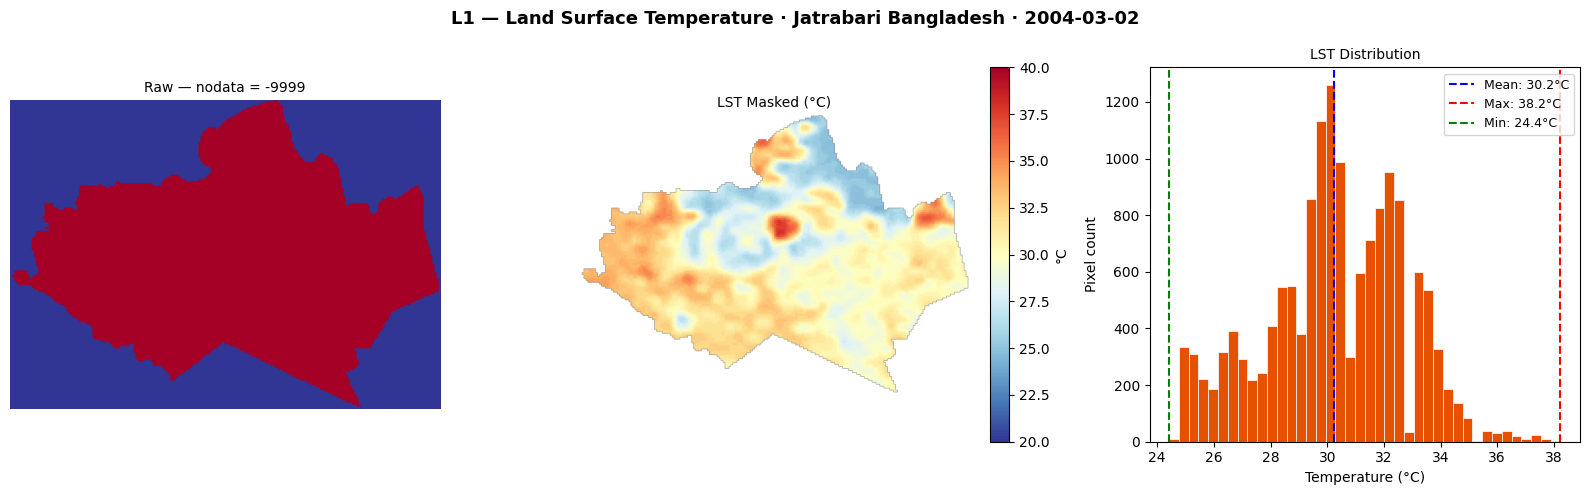

✓ Saved → outputs/figures/phase1/L1_LST_map.png


In [10]:
# ── Cell 5: Visualize Bands ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('L1 — Land Surface Temperature · Jatrabari Bangladesh · 2004-03-02',
             fontsize=13, fontweight='bold')

# Plot 1: Raw array (nodata visible as dark blue)
axes[0].imshow(lst, cmap='RdYlBu_r')
axes[0].set_title('Raw — nodata = -9999', fontsize=10)
axes[0].axis('off')

# Plot 2: Masked LST (clean temperature map)
im = axes[1].imshow(lst_masked, cmap='RdYlBu_r', vmin=20, vmax=40)
plt.colorbar(im, ax=axes[1], label='°C', fraction=0.046)
axes[1].set_title('LST Masked (°C)', fontsize=10)
axes[1].axis('off')

# Plot 3: Temperature histogram
vals = lst_masked[~np.isnan(lst_masked)].flatten()
axes[2].hist(vals, bins=40, color='#E65100', 
             edgecolor='white', linewidth=0.5)
axes[2].axvline(np.nanmean(lst_masked), color='blue',
                linestyle='--', 
                label=f'Mean: {np.nanmean(lst_masked):.1f}°C')
axes[2].axvline(np.nanmax(lst_masked), color='red',
                linestyle='--',
                label=f'Max: {np.nanmax(lst_masked):.1f}°C')
axes[2].axvline(np.nanmin(lst_masked), color='green',
                linestyle='--',
                label=f'Min: {np.nanmin(lst_masked):.1f}°C')
axes[2].set_xlabel('Temperature (°C)')
axes[2].set_ylabel('Pixel count')
axes[2].set_title('LST Distribution', fontsize=10)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'L1_LST_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → outputs/figures/phase1/L1_LST_map.png")

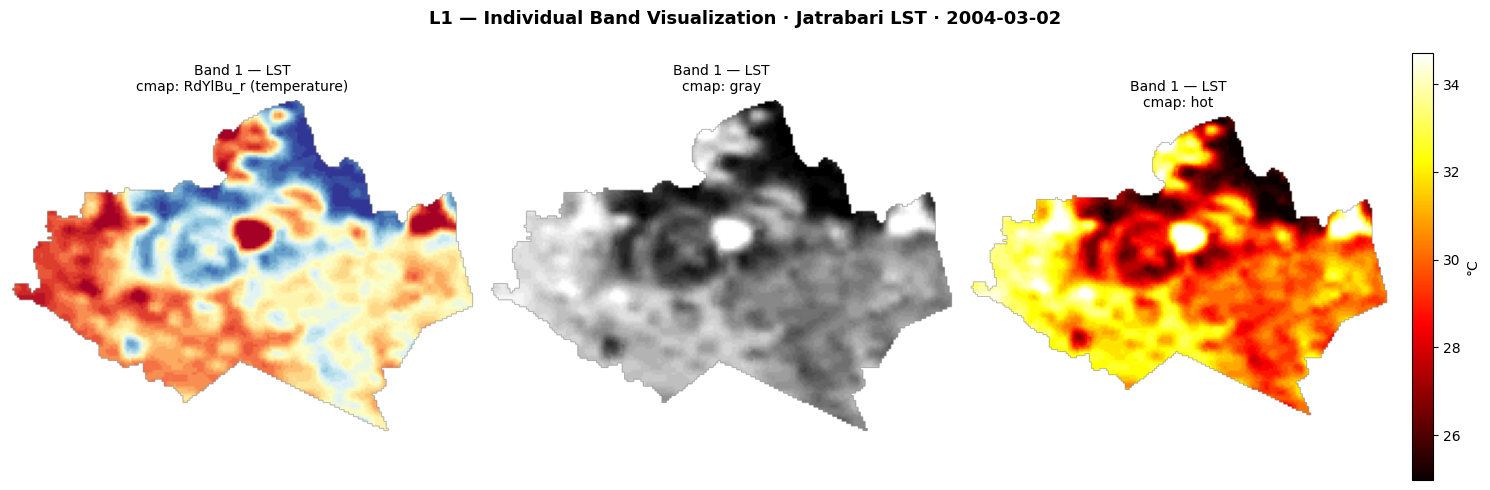

✓ Saved → outputs/figures/phase1/L1_individual_bands.png

  Band 1 — LST summary:
  Shape : (143, 199)
  Min   : 24.42 °C
  Max   : 38.23 °C
  Mean  : 30.25 °C
  2pct  : 24.98 °C  (display stretch low)
  98pct : 34.71 °C  (display stretch high)


In [11]:
# ── Cell 6: Visualize Individual Band ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('L1 — Individual Band Visualization · Jatrabari LST · 2004-03-02', 
             fontsize=13, fontweight='bold')

# ── Band 1: Default colormap ───────────────────────────────────────────────
lo = np.nanpercentile(lst_masked, 2)
hi = np.nanpercentile(lst_masked, 98)

axes[0].imshow(lst_masked, cmap='RdYlBu_r', vmin=lo, vmax=hi)
axes[0].set_title('Band 1 — LST\ncmap: RdYlBu_r (temperature)', fontsize=10)
axes[0].axis('off')

# ── Band 1: Grayscale ──────────────────────────────────────────────────────
axes[1].imshow(lst_masked, cmap='gray', vmin=lo, vmax=hi)
axes[1].set_title('Band 1 — LST\ncmap: gray', fontsize=10)
axes[1].axis('off')

# ── Band 1: Hot colormap ───────────────────────────────────────────────────
im = axes[2].imshow(lst_masked, cmap='hot', vmin=lo, vmax=hi)
plt.colorbar(im, ax=axes[2], label='°C', fraction=0.046)
axes[2].set_title('Band 1 — LST\ncmap: hot', fontsize=10)
axes[2].axis('off')

plt.tight_layout()
plt.savefig(FIG_DIR / 'L1_individual_bands.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → outputs/figures/phase1/L1_individual_bands.png")

# ── Band info summary ──────────────────────────────────────────────────────
print(f"\n  Band 1 — LST summary:")
print(f"  Shape : {lst_masked.shape}")
print(f"  Min   : {np.nanmin(lst_masked):.2f} °C")
print(f"  Max   : {np.nanmax(lst_masked):.2f} °C")
print(f"  Mean  : {np.nanmean(lst_masked):.2f} °C")
print(f"  2pct  : {lo:.2f} °C  (display stretch low)")
print(f"  98pct : {hi:.2f} °C  (display stretch high)")

---
## 🏋️ Exercise

<div style="background:#FFF9C4;border-left:4px solid #F9A825;padding:14px 20px;border-radius:0 8px 8px 0;">
<b>Task:</b> Open your Sitakunda <b>Landsat</b> TIF. Print its shape, dtype, CRS, and pixel size.<br/>
Questions to answer:
<ul style='margin:8px 0 0 0;'>
<li>What EPSG code is it in?</li>
<li>What is the pixel size compared to Sentinel-2?</li>
<li>How many bands does it have?</li>
</ul>
</div>

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────
LANDSAT_PATH = pathlib.Path("../../data/raw/YOUR_LANDSAT_FILE.tif")   # ← change

# with rasterio.open(LANDSAT_PATH) as src:
#     img_l = src.read()
#     print(img_l.shape)
#     print(src.crs)
#     ...


---
## 📝 My Notes

> _Fill in after running the code._

| Property | Sentinel-2 | Landsat |
|---|---|---|
| CRS / EPSG | `____` | `____` |
| Pixel size | `____` m | `____` m |
| Num bands | `____` | `____` |
| DN range | `____` | `____` |

**Observations:** _(write here)_

---
<div style="background:linear-gradient(135deg,#1B5E20 0%,#2E7D32 100%);padding:24px 32px;border-radius:10px;">
  <h2 style="color:#FFFFFF;margin:0 0 12px 0;font-size:18px;">✅ Key Takeaways — L1</h2>
  <ul style="color:#C8E6C9;font-size:14px;line-height:2.2;margin:0;">
    <li>Rasterio reads as <code style='background:#1B5E20;padding:2px 6px;border-radius:4px;'>(Bands, H, W)</code> — always check shape before any operation</li>
    <li>DN values are raw counts — divide by 10,000 for Sentinel-2 L2A reflectance</li>
    <li>CRS + Transform = georeferencing — always preserve when writing outputs</li>
    <li><code style='background:#1B5E20;padding:2px 6px;border-radius:4px;'>np.moveaxis(img, 0, -1)</code> → <code>(H,W,C)</code> for matplotlib</li>
    <li>Bands are 1-indexed in rasterio, 0-indexed in NumPy arrays</li>
  </ul>
</div>

---
<div style="display:flex;justify-content:space-between;padding:10px 0;font-size:13px;color:#9E9E9E;">
  <span>← Previous: (none)</span>
  <b style="color:#1565C0;">Phase 1 · L1 of 7</b>
  <span><a href='L2_spatial_profile.ipynb' style='color:#1565C0;'>Next: L2 — Spatial Profile →</a></span>
</div>